# Bag of Words Meets Bags of Popcorn Sentiment Analysis

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/word2vec-nlp-tutorial/testData.tsv.zip
/kaggle/input/competitions/word2vec-nlp-tutorial/sampleSubmission.csv
/kaggle/input/competitions/word2vec-nlp-tutorial/unlabeledTrainData.tsv.zip
/kaggle/input/competitions/word2vec-nlp-tutorial/labeledTrainData.tsv.zip


In [2]:
# =======================
# Standard Libraries
# =======================
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

# =======================
# Data & Numerical
# =======================
import pandas as pd
import numpy as np

# =======================
# Visualization
# =======================
import matplotlib.pyplot as plt
import seaborn as sns

# =======================
# NLP Libraries
# =======================
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
import re
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
nltk.download('stopwords')
import gensim
from gensim.models import Word2Vec

# =======================
# Scikit-learn (ML)
# =======================

# Model Selection
from sklearn.model_selection import train_test_split

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =======================
# Deep Learning (TensorFlow)
# =======================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, GlobalAveragePooling1D,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.layers import LSTM, Bidirectional
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2026-04-23 19:54:28.229152: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776974068.409311     104 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776974068.462326     104 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776974068.907730     104 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776974068.907773     104 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid lin

In [3]:
train = pd.read_csv('/kaggle/input/competitions/word2vec-nlp-tutorial/labeledTrainData.tsv.zip',
                    sep='\t', quoting=3)

unlabeled = pd.read_csv('/kaggle/input/competitions/word2vec-nlp-tutorial/unlabeledTrainData.tsv.zip',
                        sep='\t', quoting=3)

test = pd.read_csv('/kaggle/input/competitions/word2vec-nlp-tutorial/testData.tsv.zip',
                   sep='\t', quoting=3)

In [4]:
print("Train shape     :", train.shape)
print("Unlabeled shape :", unlabeled.shape)
print("Test shape      :", test.shape)

Train shape     : (25000, 3)
Unlabeled shape : (50000, 2)
Test shape      : (25000, 2)


In [5]:
train.head()

,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment ..."
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy ..."
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell..."
3,"""3630_4""",0,"""It must be assumed that those who praised thi..."
4,"""9495_8""",1,"""Superbly trashy and wondrously unpretentious ..."



 sentiment
1    12500
0    12500
Name: count, dtype: int64


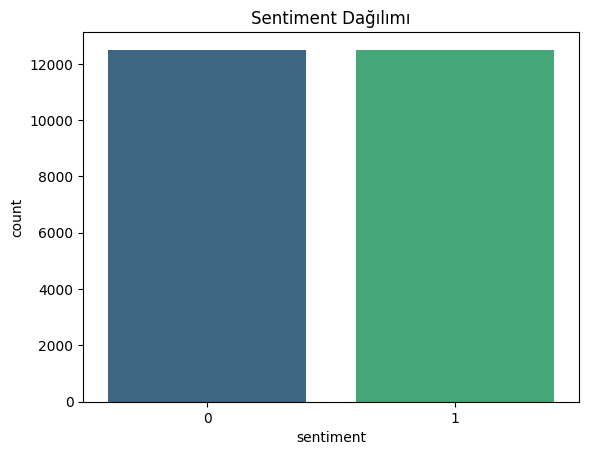

In [6]:
# Sentiment distribution
print("\n", train['sentiment'].value_counts())
sns.countplot(x='sentiment', data=train, palette='viridis')
plt.title("Sentiment Dağılımı")
plt.show()

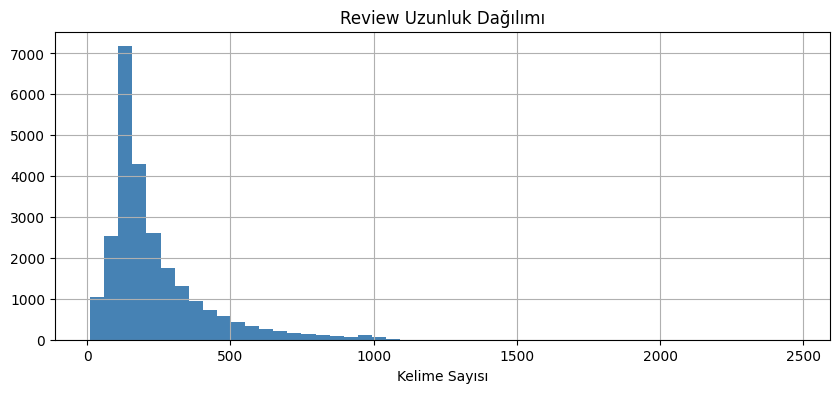

In [7]:
# Review lenght
train['review_len'] = train['review'].apply(lambda x: len(str(x).split()))
train['review_len'].hist(bins=50, figsize=(10,4), color='steelblue')
plt.title("Review Uzunluk Dağılımı")
plt.xlabel("Kelime Sayısı")
plt.show()

In [8]:
print("Ortalama uzunluk :", train['review_len'].mean())
print("Max uzunluk      :", train['review_len'].max())
print("Min uzunluk      :", train['review_len'].min())

Ortalama uzunluk : 233.78824
Max uzunluk      : 2470
Min uzunluk      : 10


In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = BeautifulSoup(text, 'html.parser').get_text()  # HTML kaldır
    text = re.sub(r'[^a-zA-Z]', ' ', text)                # sadece harf
    text = text.lower()                                   # küçük harf
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]   # stopword kaldır
    return ' '.join(tokens)

train['review'] = train['review'].apply(clean_text)
unlabeled['review'] = unlabeled['review'].apply(clean_text)
test['review'] = test['review'].apply(clean_text)

In [10]:
train['review'][0]

'stuff going moment mj started listening music watching odd documentary watched wiz watched moonwalker maybe want get certain insight guy thought really cool eighties maybe make mind whether guilty innocent moonwalker part biography part feature film remember going see cinema originally released subtle messages mj feeling towards press also obvious message drugs bad kay visually impressive course michael jackson unless remotely like mj anyway going hate find boring may call mj egotist consenting making movie mj fans would say made fans true really nice actual feature film bit finally starts minutes excluding smooth criminal sequence joe pesci convincing psychopathic powerful drug lord wants mj dead bad beyond mj overheard plans nah joe pesci character ranted wanted people know supplying drugs etc dunno maybe hates mj music lots cool things like mj turning car robot whole speed demon sequence also director must patience saint came filming kiddy bad sequence usually directors hate workin

In [11]:
x = train['review']
y = train['sentiment']

In [12]:
# Train / Val split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

## TF-IDF + ML

In [13]:
#Vektorization
# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)

In [14]:
x_train_tf  = tfidf.fit_transform(x_train)
x_val_tf = tfidf.transform(x_val)
x_test_tf = tfidf.transform(test['review'])

In [15]:
modeller = {
    'BernoulliNB'              : BernoulliNB(),
    'LogisticRegression'       : LogisticRegression(),
    'DecisionTreeClassifier'   : DecisionTreeClassifier(),
    'RandomForestClassifier'   : RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'KNeighborsClassifier'     : KNeighborsClassifier(),
    'AdaBoostClassifier'       : AdaBoostClassifier(),
    'MultinomialNB'            : MultinomialNB(),
}

sonuclar = {}

for isim, model in modeller.items():
    model.fit(x_train_tf, y_train)
    tahmin = model.predict(x_val_tf)
    
    sonuclar[isim] = {
        'Accuracy' : accuracy_score(y_val, tahmin),
        'Precision': precision_score(y_val, tahmin, average='micro'),
        'Recall'   : recall_score(y_val, tahmin, average='micro'),
        'F1'       : f1_score(y_val, tahmin, average='micro'),
    }
    print(f"{isim}: {sonuclar[isim]['F1']:.4f}")

metrics = pd.DataFrame(sonuclar).T.sort_values('F1', ascending=False)
print(metrics)
print(f"\nEn iyi model: {metrics.index[0]}")

BernoulliNB: 0.8552
LogisticRegression: 0.8874
DecisionTreeClassifier: 0.7142
RandomForestClassifier: 0.8482
GradientBoostingClassifier: 0.8080
KNeighborsClassifier: 0.7944
AdaBoostClassifier: 0.7474
MultinomialNB: 0.8642
                            Accuracy  Precision  Recall      F1
LogisticRegression            0.8874     0.8874  0.8874  0.8874
MultinomialNB                 0.8642     0.8642  0.8642  0.8642
BernoulliNB                   0.8552     0.8552  0.8552  0.8552
RandomForestClassifier        0.8482     0.8482  0.8482  0.8482
GradientBoostingClassifier    0.8080     0.8080  0.8080  0.8080
KNeighborsClassifier          0.7944     0.7944  0.7944  0.7944
AdaBoostClassifier            0.7474     0.7474  0.7474  0.7474
DecisionTreeClassifier        0.7142     0.7142  0.7142  0.7142

En iyi model: LogisticRegression


              precision    recall  f1-score   support

    negative       0.90      0.87      0.89      2500
    positive       0.88      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



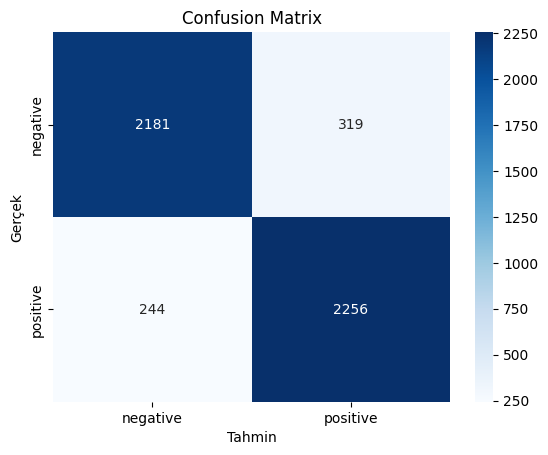

In [16]:
best_model = LogisticRegression()
best_model.fit(x_train_tf, y_train)
best_pred = best_model.predict(x_val_tf)

print(classification_report(y_val, best_pred,
      target_names=['negative', 'positive']))

cm = confusion_matrix(y_val, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','positive'],
            yticklabels=['negative','positive'])
plt.title("Confusion Matrix")
plt.ylabel("Gerçek")
plt.xlabel("Tahmin")
plt.show()

In [17]:
# En iyi model ile eğitelim
x = tfidf.fit_transform(train['review'])

best_model.fit(x, y)
final_pred = best_model.predict(x_test_tf)

# Submission
submission1 = pd.DataFrame({
    'id'       : test['id'],
    'sentiment': final_pred
})

In [18]:
submission1.head(10)

,id,sentiment
0,"""12311_10""",0
1,"""8348_2""",0
2,"""5828_4""",1
3,"""7186_2""",1
4,"""12128_7""",0
5,"""2913_8""",0
6,"""4396_1""",1
7,"""395_2""",0
8,"""10616_1""",0
9,"""9074_9""",0


In [19]:
submission1['id'] = submission1['id'].str.replace('"', '')
submission1.head()

,id,sentiment
0,12311_10,0
1,8348_2,0
2,5828_4,1
3,7186_2,1
4,12128_7,0


## Word2Vec + ML

In [20]:
#Word2Vec için tokenize edilmiş bir liste gerekli
train_sentences    = train['review'].str.split().tolist()
unlabeled_sentences = unlabeled['review'].str.split().tolist()

all_sentences = train_sentences + unlabeled_sentences

print("Toplam cümle sayısı:", len(all_sentences))
print("Örnek:", all_sentences[0][:10])

Toplam cümle sayısı: 75000
Örnek: ['stuff', 'going', 'moment', 'mj', 'started', 'listening', 'music', 'watching', 'odd', 'documentary']


In [21]:
# Word2Vec modelini eeğitelim
w2v_model = Word2Vec(
    sentences=all_sentences,
    vector_size=100,      # her kelime 100 boyutlu vektör
    window=5,             # bağlam penceresi
    min_count=2,          # en az 2 kez geçen kelimeler
    workers=4,            # paralel işlem
    epochs=10,
    sg=1                  # 1=Skip-Gram, 0=CBOW
)

In [22]:
def review_to_vector(review, model, vector_size=100):
    words  = review.split()
    # Modelde olan kelimelerin vektörlerini al
    vecs   = [model.wv[w] for w in words if w in model.wv]
    
    if len(vecs) == 0:
        return np.zeros(vector_size)   # hiç kelime yoksa sıfır vektör
    
    return np.mean(vecs, axis=0)       # ortalama vektör

# Train, val, test vektörleri
x_w2v = np.array([review_to_vector(r, w2v_model) 
                   for r in train['review']])

x_test_w2v = np.array([review_to_vector(r, w2v_model) 
                        for r in test['review']])

In [23]:
y = train['sentiment']

x_train, x_val, y_train, y_val = train_test_split(
    x_w2v, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'SVC'                : SVC(kernel='rbf', C=1.0, probability=True),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

ml_results = {}

for name, model in ml_models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_val)
    acc  = accuracy_score(y_val, pred)
    ml_results[name] = {'model': model, 'acc': acc}
    print(f"{name}: {acc:.4f}")

best_name  = max(ml_results, key=lambda k: ml_results[k]['acc'])
best_model = ml_results[best_name]['model']
best_acc   = ml_results[best_name]['acc']

print(f"\nEn iyi: {best_name} → {best_acc:.4f}")

Logistic Regression: 0.8800
SVC: 0.8810
Random Forest: 0.8474
Gradient Boosting: 0.8548

En iyi: SVC → 0.8810


              precision    recall  f1-score   support

    negative       0.88      0.88      0.88      2500
    positive       0.88      0.89      0.88      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



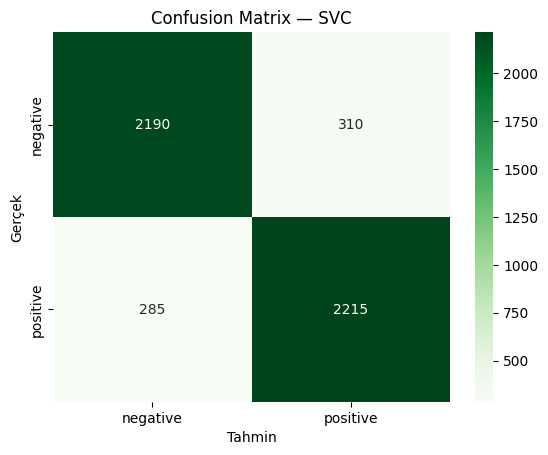

In [25]:
# Confusion Matrix
best_pred = best_model.predict(x_val)
print(classification_report(y_val, best_pred,
      target_names=['negative','positive']))

cm = confusion_matrix(y_val, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative','positive'],
            yticklabels=['negative','positive'])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Gerçek")
plt.xlabel("Tahmin")
plt.show()

In [26]:
# En iyi model ile eğitelim
best_model = SVC(kernel='rbf', C=1.0, probability=True)

best_model.fit(x_w2v, y)
final_pred = best_model.predict(x_test_w2v)

submission2 = pd.DataFrame({
    'id'       : test['id'],
    'sentiment': final_pred.astype(int)
})

submission2['id'] = submission2['id'].str.replace('"', '')

In [27]:
submission2.head(10)

,id,sentiment
0,12311_10,1
1,8348_2,0
2,5828_4,1
3,7186_2,0
4,12128_7,1
5,2913_8,1
6,4396_1,0
7,395_2,0
8,10616_1,0
9,9074_9,1


## Word2Vec + Deep Learning

In [28]:
#Tokenizer & Sequence

MAX_WORDS = 10000
MAX_LEN   = 200    # review'lar uzun olduğu için 200
EMBED_DIM = 100    # Word2Vec ile aynı boyut

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train['review'])

# Sequence'e çevir
x_seq      = tokenizer.texts_to_sequences(train['review'])
x_test_seq = tokenizer.texts_to_sequences(test['review'])

# Padding
x_pad      = pad_sequences(x_seq,      maxlen=MAX_LEN, padding='post', truncating='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')


In [29]:
# Word2Vec → Embedding Matrix
# Word2Vec ağırlıklarını Keras Embedding katmanına aktar
word_index = tokenizer.word_index

embedding_matrix = np.zeros((MAX_WORDS, EMBED_DIM))

matched   = 0
unmatched = 0

for word, idx in word_index.items():
    if idx < MAX_WORDS:
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
            matched += 1
        else:
            unmatched += 1

In [30]:
y = train['sentiment']

x_train, x_val, y_train, y_val = train_test_split(
    x_pad, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
# GlobalAveragePooling
gap_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),          # W2V ağırlıklarını dondur
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

gap_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

I0000 00:00:1776974934.957389     104 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [32]:
gap_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [33]:
#LSTM MODEL
lstm_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [34]:
#CNN 
cnn_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [35]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

dl_models = {
    'GAP'  : gap_model,
    'LSTM' : lstm_model,
    'CNN'  : cnn_model
}

dl_results = {}

for name, model in dl_models.items():
    print(f"\n{'='*40}")
    print(f"🔄 Eğitiliyor: {name}")
    print(f"{'='*40}")
    
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=30,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )
    
    pred_prob = model.predict(x_val)
    pred      = (pred_prob > 0.5).astype(int).flatten()
    acc       = accuracy_score(y_val, pred)
    
    dl_results[name] = {'model': model, 'acc': acc, 'history': history}
    print(f"{name} Val Accuracy: {acc:.4f}")

# En iyi DL modeli
best_dl_name  = max(dl_results, key=lambda k: dl_results[k]['acc'])
best_dl_acc   = dl_results[best_dl_name]['acc']
print(f"En iyi DL: {best_dl_name} → {best_dl_acc:.4f}")


🔄 Eğitiliyor: GAP
Epoch 1/30


I0000 00:00:1776974938.085263     222 service.cc:152] XLA service 0x7f469400a5a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776974938.085298     222 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776974938.456112     222 cuda_dnn.cc:529] Loaded cuDNN version 91002


 54/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6446 - loss: 0.6446

I0000 00:00:1776974940.103015     222 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7541 - loss: 0.4952 - val_accuracy: 0.8356 - val_loss: 0.5138 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8532 - loss: 0.3384 - val_accuracy: 0.8698 - val_loss: 0.3153 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8636 - loss: 0.3308 - val_accuracy: 0.8710 - val_loss: 0.3085 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8633 - loss: 0.3310 - val_accuracy: 0.8752 - val_loss: 0.2994 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8689 - loss: 0.3137 - val_accuracy: 0.8728 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8635 - loss: 0.3188 - val_accuracy: 0.8764 - val_loss: 0.2956 - learning_rate: 0.0010
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8661 - loss: 0.3054 - val_accura

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
              precision    recall  f1-score   support

    negative       0.92      0.86      0.89      2500
    positive       0.87      0.92      0.90      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



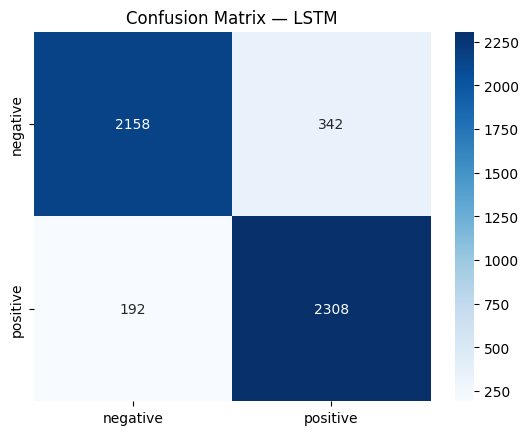

In [36]:
# Confusion Matrix - DL 
best_pred = (lstm_model.predict(x_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, best_pred, target_names=['negative', 'positive']))

cm = confusion_matrix(y_val, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title("Confusion Matrix — LSTM")
plt.show()

In [37]:
# Submission
final_pred = (lstm_model.predict(x_test_pad) > 0.5).astype(int).flatten()

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step


In [40]:
submission = pd.DataFrame({
    'id'       : test['id'].str.replace('"', ''),
    'sentiment': final_pred
})

In [41]:
submission.head(10)

,id,sentiment
0,12311_10,1
1,8348_2,0
2,5828_4,1
3,7186_2,0
4,12128_7,1
5,2913_8,1
6,4396_1,0
7,395_2,1
8,10616_1,0
9,9074_9,1


In [42]:
submission.to_csv('submission.csv', index=False)

In [43]:
model.save('bagofwords_model.h5')

In [44]:
model.save('bagofwords_model.keras')